Titanic survival analysis
Data analysis project using python, numpy, pandas, and matplotlib

Data source: titanic.csv
Libraries used: numpy, pandas, matplotlib

Questions
1. What was the survival rate
2. Did passenger class affect survival
3. Did gender affect survival
4. What was the age distrobution of passengers
5. Did passengers paying higher fairs have a higher rate of survival
6. Which port had the highest survival rate

In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn
import sys
!{sys.executable} -m pip install matplotlib

  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
url = "https://raw.githubusercontent.com/pandas-dev/pandas/main/doc/data/titanic.csv"
df = pd.read_csv(url)
df.head()

Matplotlib is building the font cache; this may take a moment.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Cleaning
We load the dataset using the URL and pandas read_csv().
Missing values:
Age: filled with median age
Embarked: filled with the most common port
Cabin: dropped because 70% of the values are missing

In [6]:
df.shape

(891, 12)

In [7]:
df.describe

<bound method NDFrame.describe of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                                Heikkinen, Miss Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                 

In [8]:
df.info()
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [10]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df.drop(columns=["Cabin"], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


Overall survival rate: 38.4%
Total survivors: 342
Total did not survive: 549


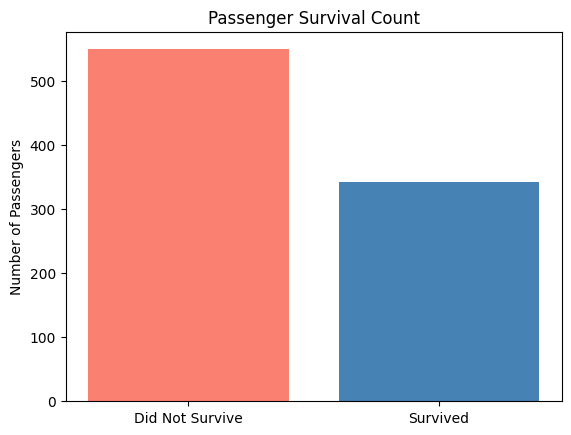

In [5]:
survived = df[df["Survived"] == 1]
not_survived = df[df["Survived"] == 0]

survival_rate = df["Survived"].mean() * 100
print(f"Overall survival rate: {survival_rate:.1f}%")
print(f"Total survivors: {len(survived)}")
print(f"Total did not survive: {len(not_survived)}")


fig, ax = plt.subplots(1, 1)
ax.bar(["Did Not Survive", "Survived"], 
       [len(not_survived), len(survived)], 
       color=["salmon", "steelblue"])
ax.set_title("Passenger Survival Count")
ax.set_ylabel("Number of Passengers")
plt.show()

Q1 Answer:
Only 38.4% of passengers survived.
Out of 891 passengers, 342 survived and 549 didn't. 

Q2:
Used groupby() to calculate the average survival rate for each of the passenger classes.

Survival rate by class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


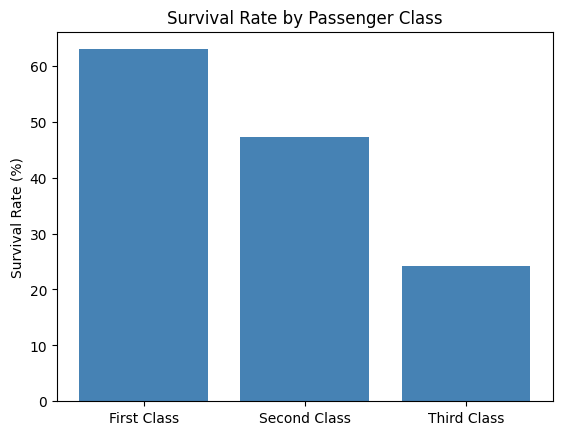

In [6]:
class_survival = df.groupby("Pclass")["Survived"].mean() * 100
print("Survival rate by class:")
print(class_survival)

fig, ax = plt.subplots(1, 1)
ax.bar(["First Class", "Second Class", "Third Class"],
       class_survival.values,
       color="steelblue")
ax.set_title("Survival Rate by Passenger Class")
ax.set_ylabel("Survival Rate (%)")
plt.show()

In [ ]:
Q3 Answer:
There was a major correlation between passenger class and survival rate. 
First class passengers had the highest survival rate, and third class 
passengers had the lowest. Wealth and social status affected passenger class, 
and passenger class clearly played a role in who had access to lifeboats.

Q3:
We use .loc[] to filter by gender and compare the survival rates between the different genders

Female survival rate: 74.2%
Male survival rate: 18.9%


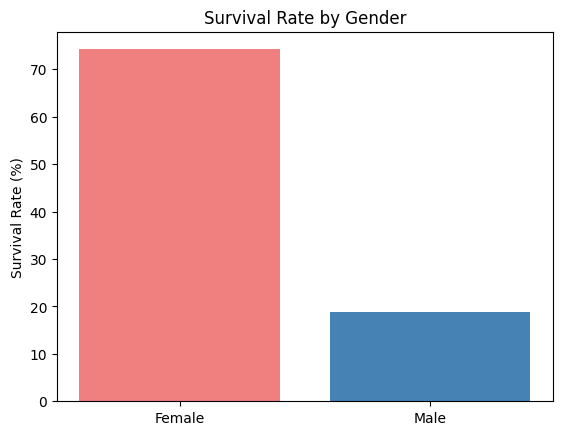

In [7]:
female_survival = df.loc[df["Sex"] == "female", "Survived"].mean() * 100
male_survival = df.loc[df["Sex"] == "male", "Survived"].mean() * 100

print(f"Female survival rate: {female_survival:.1f}%")
print(f"Male survival rate: {male_survival:.1f}%")

fig, ax = plt.subplots(1, 1)
ax.bar(["Female", "Male"], [female_survival, male_survival],
       color=["lightcoral", "steelblue"])
ax.set_title("Survival Rate by Gender")
ax.set_ylabel("Survival Rate (%)")
plt.show()

Q3 Answer:
Gender was the strongest predictor of survival I've seen so far. Women survived at a much higher rate than men. This is because the rule during crisis at the time was to get the women and children out first.

Q4:
We use a histogram with 20 bins to show the spread of passenger ages across the dataset.

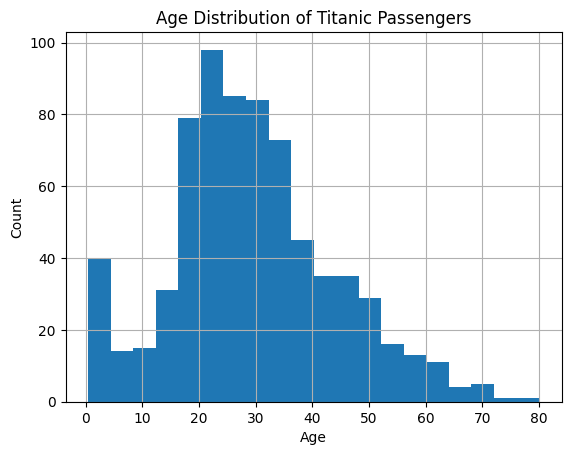

In [8]:
fig, ax = plt.subplots(1, 1)
ax.hist(df["Age"], bins=20)
ax.set_title("Age Distribution of Titanic Passengers")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
plt.grid(True)
plt.show()

Q4 answer:
Most passengers were between 20 and 40. There was a notable number of children under 10. The distrobution is almost normal, but it has a slight right skew surprisingly.

Q5:
Used numpy arrays and stacking subplots to compare the age distributions of survivors vs non-survivors side by side.

Mean age of survivors: nan
Mean age of non-survivors: nan


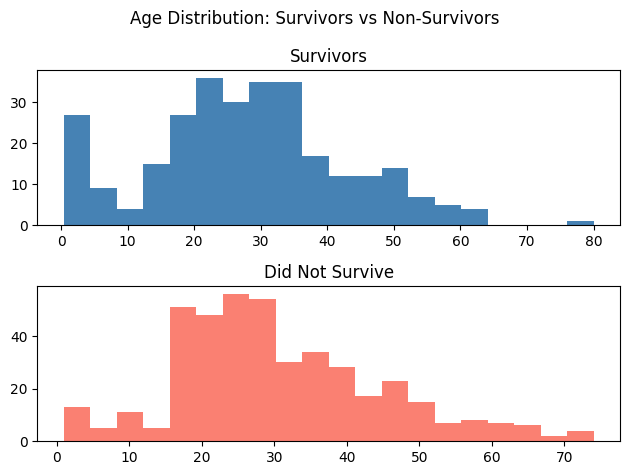

In [9]:
survivor_ages = np.array(df.loc[df["Survived"] == 1, "Age"])
nonsurvivor_ages = np.array(df.loc[df["Survived"] == 0, "Age"])

print(f"Mean age of survivors: {survivor_ages.mean():.1f}")
print(f"Mean age of non-survivors: {nonsurvivor_ages.mean():.1f}")

fig, (ax1, ax2) = plt.subplots(2)
fig.suptitle("Age Distribution: Survivors vs Non-Survivors")
ax1.hist(survivor_ages, bins=20, color="steelblue")
ax1.set_title("Survivors")
ax2.hist(nonsurvivor_ages, bins=20, color="salmon")
ax2.set_title("Did Not Survive")
plt.tight_layout()
plt.show()

Q5 answer:
Survivors and non-survivors had similar average ages, but children under 10 had a very noticeably higher survival rate. This also tends to support the women and children first policy that was popular during this time.

In [ ]:
Q6:
Used groupby() on the embarked column to compare survival rates across the three 
ports.

Embarked
C    55.357143
Q    38.961039
S    33.695652
Name: Survived, dtype: float64


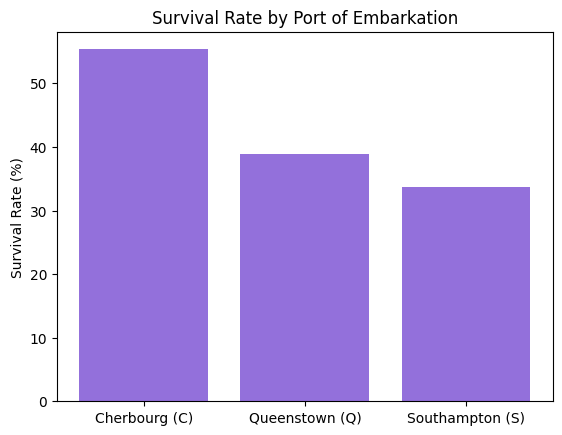

In [10]:
port_survival = df.groupby("Embarked")["Survived"].mean() * 100
print(port_survival)

fig, ax = plt.subplots(1, 1)
ax.bar(["Cherbourg (C)", "Queenstown (Q)", "Southampton (S)"],
       port_survival.values,
       color="mediumpurple")
ax.set_title("Survival Rate by Port of Embarkation")
ax.set_ylabel("Survival Rate (%)")
plt.show()

Q6 answer:
Passengers who boarded at Cherbourg had the highest survival rate. This is probably because there were more first class passengers from that port leading to the higher survival rate. 

Average fare paid: $32.20
Max fare paid: $512.33
Min fare paid: $0.00


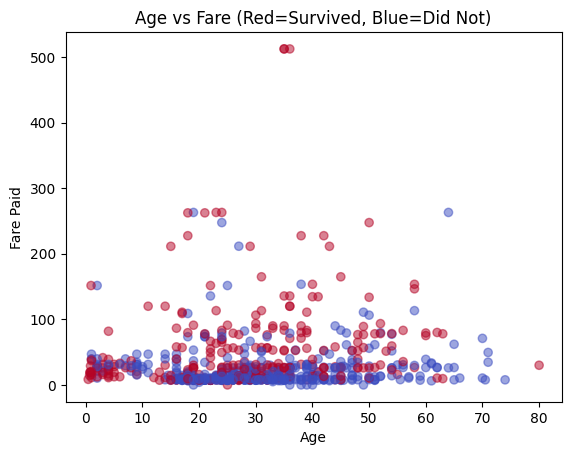

In [11]:
fares = np.array(df["Fare"])
print(f"Average fare paid: ${fares.mean():.2f}")
print(f"Max fare paid: ${fares.max():.2f}")
print(f"Min fare paid: ${fares.min():.2f}")

fig, ax = plt.subplots(1, 1)
ax.scatter(df["Age"], df["Fare"],
           c=df["Survived"],
           cmap="coolwarm", alpha=0.5)
ax.set_title("Age vs Fare (Red=Survived, Blue=Did Not)")
ax.set_xlabel("Age")
ax.set_ylabel("Fare Paid")
plt.show()

Conclusions:
- Less than 40% of passengers survived
- First class passengers survived at almost double the rate of third class
- Women survived at a much higher rate than men
- Children under 10 also had better survival odds than adults and men alike
- Where you boarded the ship DID correlate with survival chances, but that is most likely due to the distrobution of passengers in higher classes from certain ports

Who cares?
Historians, policy makers, and engineers can use this data to understand how social inequality can affect survival rate in disasters.

Limitations:
- The data is incomplete and only covers 891 of the 2000+ people on board
- Self-reported ages COULD have inaccuracies but I doubt how much that really affected the data

Conclusion:
Survival on the titanic wasn't completely random. Class, gender, and age all played significant roles in determining who lived.